# 02 - Análisis descriptivo del consumo eléctrico

En este cuaderno se realiza un análisis descriptivo del consumo eléctrico del hogar a partir del archivo `household_power_consumption.csv` ubicado en la carpeta `data`.

In [13]:
from pathlib import Path

import numpy as np
import pandas as pd
import matplotlib.pyplot as plt
import seaborn as sns

%matplotlib inline
sns.set(style="whitegrid")

## Carga del dataset desde `data/household_power_consumption.csv`

In [14]:
csv_path = Path("..") / "data" / "cleaned_energy_data.csv"
df = pd.read_csv(csv_path)

df.head()

C:\Users\frany\AppData\Local\Temp\ipykernel_6672\2511698529.py:2: DtypeWarning: Columns (3,4,5,6,7) have mixed types. Specify dtype option on import or set low_memory=False.
  df = pd.read_csv(csv_path)


,Date,Time,Global_active_power,Global_reactive_power,Voltage,Global_intensity,Sub_metering_1,Sub_metering_2,Sub_metering_3
0,16/12/2006,17:24:00,4.216,0.418,234.840,18.400,0.000,1.000,17.0
1,16/12/2006,17:25:00,5.360,0.436,233.630,23.000,0.000,1.000,16.0
2,16/12/2006,17:26:00,5.374,0.498,233.290,23.000,0.000,2.000,17.0
3,16/12/2006,17:27:00,5.388,0.502,233.740,23.000,0.000,1.000,17.0
4,16/12/2006,17:28:00,3.666,0.528,235.680,15.800,0.000,1.000,17.0


## Estructura general y tipos de datos

In [15]:
df.info()

<class 'pandas.core.frame.DataFrame'>
RangeIndex: 2075259 entries, 0 to 2075258
Data columns (total 9 columns):
 #   Column                 Dtype  
---  ------                 -----  
 0   Date                   object 
 1   Time                   object 
 2   Global_active_power    float64
 3   Global_reactive_power  object 
 4   Voltage                object 
 5   Global_intensity       object 
 6   Sub_metering_1         object 
 7   Sub_metering_2         object 
 8   Sub_metering_3         float64
dtypes: float64(2), object(7)
memory usage: 142.5+ MB


In [16]:
df.describe(include="all")

,Date,Time,Global_active_power,Global_reactive_power,Voltage,Global_intensity,Sub_metering_1,Sub_metering_2,Sub_metering_3
count,2075259,2075259,2.049280e+06,2075259,2075259,2075259,2075259,2075259,2.049280e+06
unique,1442,1440,NaN,896,5168,377,153,145,NaN
top,6/12/2008,17:24:00,NaN,0.000,?,1.000,0.000,0.000,NaN
freq,1440,1442,NaN,472786,25979,169406,1840611,1408274,NaN
mean,NaN,NaN,1.091615e+00,NaN,NaN,NaN,NaN,NaN,6.458447e+00
std,NaN,NaN,1.057294e+00,NaN,NaN,NaN,NaN,NaN,8.437154e+00
min,NaN,NaN,7.600000e-02,NaN,NaN,NaN,NaN,NaN,0.000000e+00
25%,NaN,NaN,3.080000e-01,NaN,NaN,NaN,NaN,NaN,0.000000e+00
50%,NaN,NaN,6.020000e-01,NaN,NaN,NaN,NaN,NaN,1.000000e+00
75%,NaN,NaN,1.528000e+00,NaN,NaN,NaN,NaN,NaN,1.700000e+01


## Creación de índice temporal a partir de fecha y hora

In [17]:
date_col = [c for c in df.columns if c.lower() == "date"][0]
time_col = [c for c in df.columns if c.lower() == "time"][0]

df["datetime"] = pd.to_datetime(df[date_col] + " " + df[time_col], dayfirst=True, errors="coerce")
df = df.set_index("datetime").sort_index()

df[[date_col, time_col]].head()

,Date,Time
datetime,,
2006-12-16 17:24:00,16/12/2006,17:24:00
2006-12-16 17:25:00,16/12/2006,17:25:00
2006-12-16 17:26:00,16/12/2006,17:26:00
2006-12-16 17:27:00,16/12/2006,17:27:00
2006-12-16 17:28:00,16/12/2006,17:28:00


## Valores faltantes por columna

In [18]:
df.isna().mean().sort_values(ascending=False)

Global_active_power      0.012518
Sub_metering_3           0.012518
Date                     0.000000
Time                     0.000000
Global_reactive_power    0.000000
Voltage                  0.000000
Global_intensity         0.000000
Sub_metering_1           0.000000
Sub_metering_2           0.000000
dtype: float64

In [19]:
df.columns

Index(['Date', 'Time', 'Global_active_power', 'Global_reactive_power',
       'Voltage', 'Global_intensity', 'Sub_metering_1', 'Sub_metering_2',
       'Sub_metering_3'],
      dtype='object')

In [20]:
df['Global_active_power'] = df['Global_active_power'].astype(float)

## Distribución de la potencia activa global

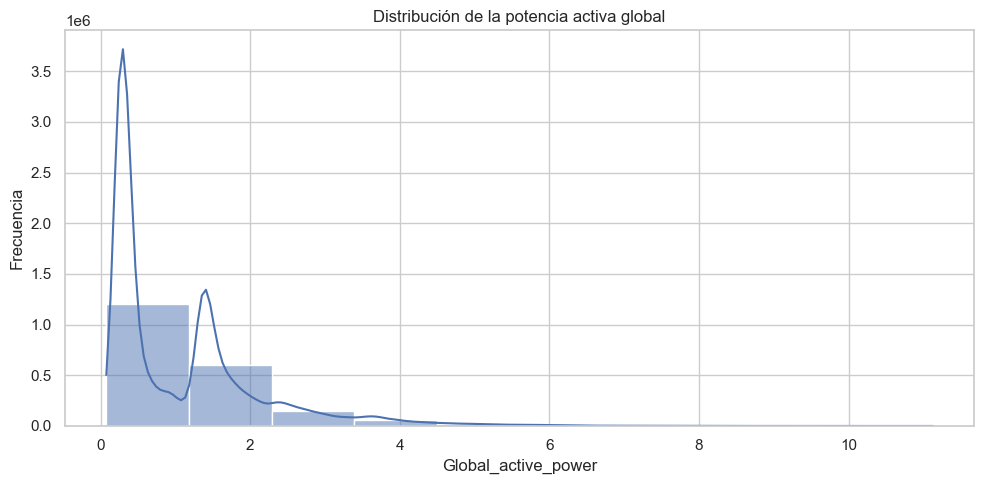

In [26]:
gap_col = [c for c in df.columns if c.lower() == "global_active_power"][0]

plt.figure(figsize=(10, 5))
sns.histplot(df[gap_col].dropna(), bins=10, kde=True)
plt.xlabel(gap_col)
plt.ylabel("Frecuencia")
plt.title("Distribución de la potencia activa global")
plt.tight_layout()

## Serie temporal de un periodo de ejemplo

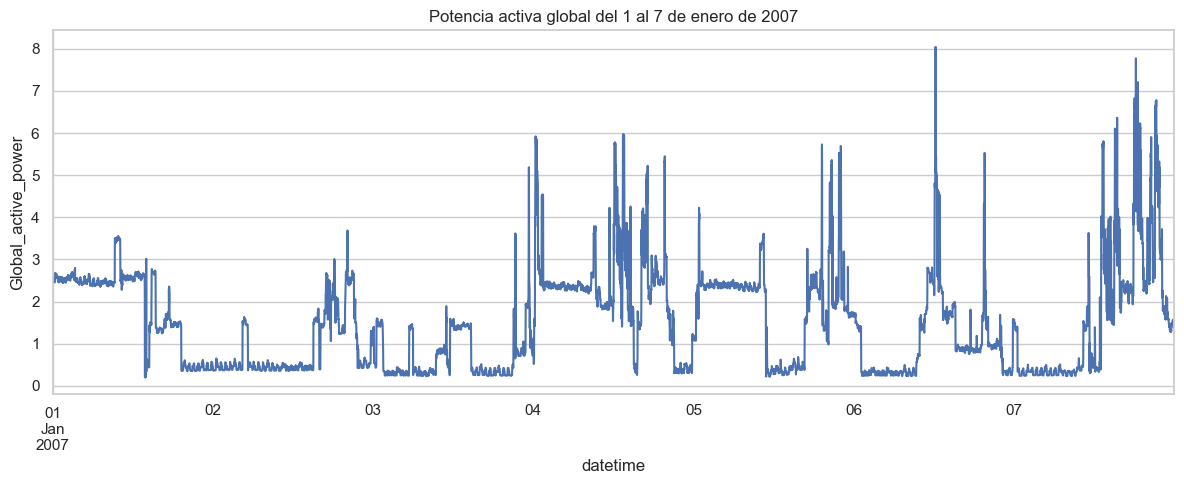

In [27]:
sample_period = df.loc["2007-01-01":"2007-01-07"]

plt.figure(figsize=(12, 5))
sample_period[gap_col].plot()
plt.ylabel(gap_col)
plt.title("Potencia activa global del 1 al 7 de enero de 2007")
plt.tight_layout()

## Relación entre submediciones y potencia activa global

In [29]:
df.columns

Index(['Date', 'Time', 'Global_active_power', 'Global_reactive_power',
       'Voltage', 'Global_intensity', 'Sub_metering_1', 'Sub_metering_2',
       'Sub_metering_3'],
      dtype='object')

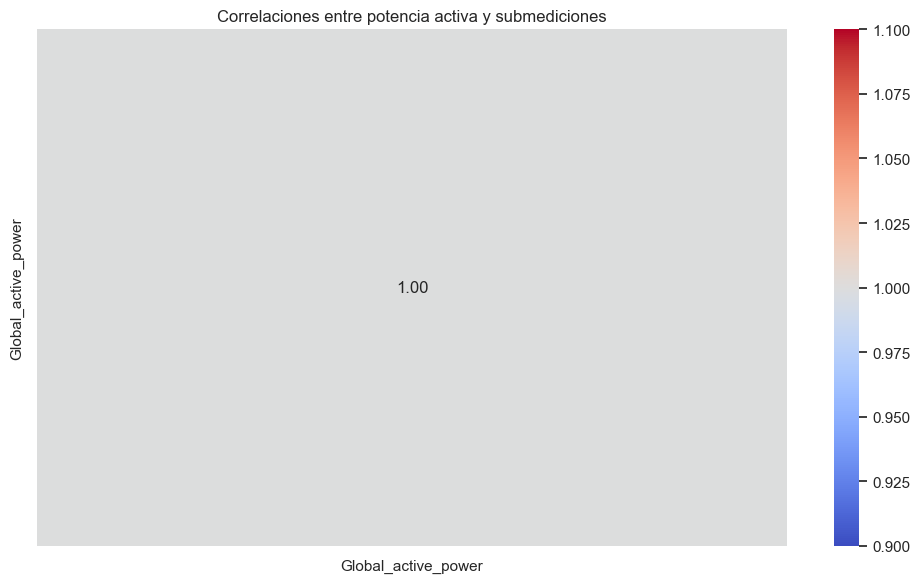

In [32]:
sub_cols = [c for c in df.columns if "Sub_metering_1" in c.lower()]

plt.figure(figsize=(10, 6))
sns.heatmap(df[[gap_col] + sub_cols].corr(), annot=True, cmap="coolwarm", fmt=".2f")
plt.title("Correlaciones entre potencia activa y submediciones")
plt.tight_layout()